In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Exam_Score_Prediction.csv")
print(df.head())

   student_id  age  gender   course  study_hours  class_attendance  \
0           1   17    male  diploma         2.78              92.9   
1           2   23   other      bca         3.37              64.8   
2           3   22    male     b.sc         7.88              76.8   
3           4   20   other  diploma         0.67              48.4   
4           5   20  female  diploma         0.89              71.6   

  internet_access  sleep_hours sleep_quality   study_method facility_rating  \
0             yes          7.4          poor       coaching             low   
1             yes          4.6       average  online videos          medium   
2             yes          8.5          poor       coaching            high   
3             yes          5.8       average  online videos             low   
4             yes          9.8          poor       coaching             low   

  exam_difficulty  exam_score  
0            hard        58.9  
1        moderate        54.8  
2       

In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(20000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB
None
         student_id           age   study_hours  class_attendance  \
count  20000.000000  20000.000000  200

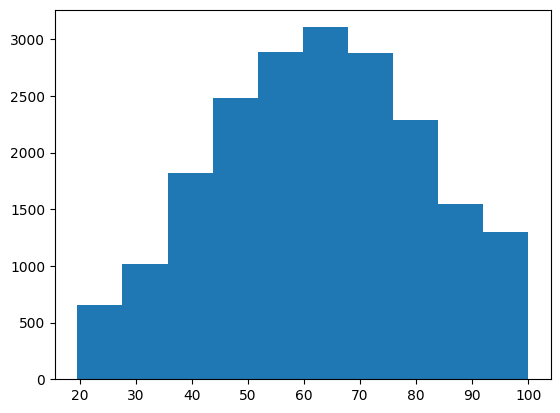

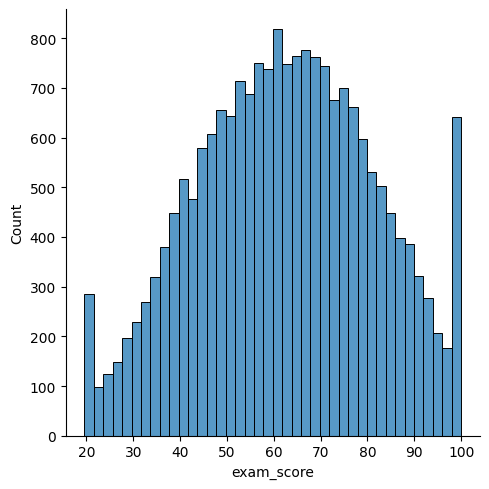

In [4]:
plt.hist(df['exam_score'])
sns.displot(df['exam_score'])
plt.show()

In [5]:
print(df['exam_score'].skew())

-0.04905862218606845


exam_difficulty
moderate    9878
easy        6141
hard        3981
Name: count, dtype: int64


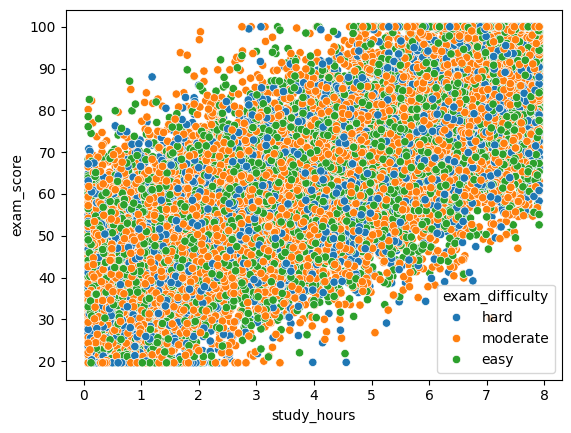

In [6]:
#df = df.sample(1000)
print(df['exam_difficulty'].value_counts())
sns.scatterplot(x = df['study_hours'],y =df['exam_score'],hue=df['exam_difficulty'])
plt.show()

In [7]:
df.groupby('facility_rating')['exam_score'].mean()


facility_rating
high      66.165916
low       58.594346
medium    62.794061
Name: exam_score, dtype: float64

<Axes: xlabel='sleep_quality', ylabel='exam_score'>

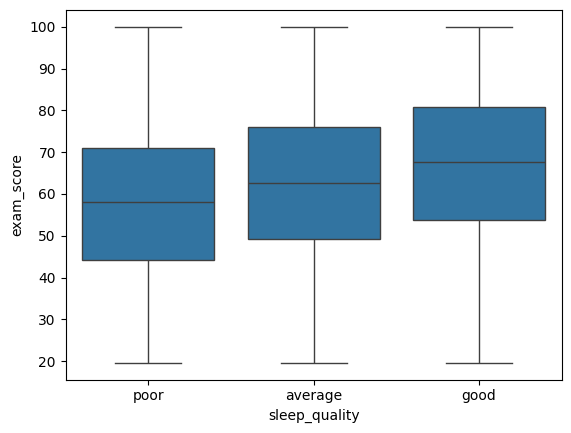

In [8]:
sns.boxplot(x= df['sleep_quality'],y =df['exam_score'])

In [9]:
df.select_dtypes(include='number').corr()['exam_score'].sort_values(ascending=False)

exam_score          1.000000
study_hours         0.717788
class_attendance    0.308850
sleep_hours         0.133222
age                 0.006522
student_id          0.003269
Name: exam_score, dtype: float64

<Axes: xlabel='class_attendance', ylabel='exam_score'>

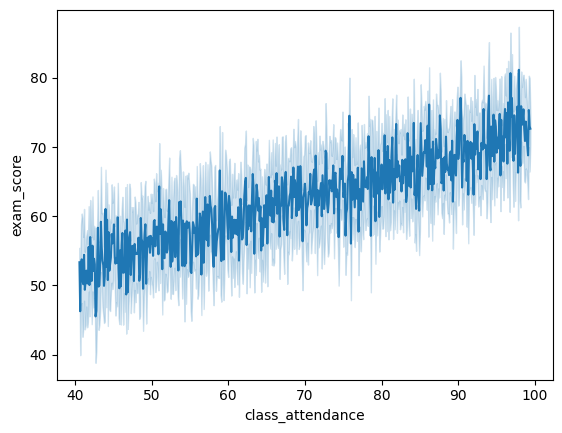

In [10]:
sns.lineplot(x =df['class_attendance'],y =df['exam_score'])

In [11]:
df = df.drop(columns=['student_id','gender'])

In [12]:
df = df.drop(columns="internet_access")

In [13]:
print(df.head())
print(df.shape)

   age   course  study_hours  class_attendance  sleep_hours sleep_quality  \
0   17  diploma         2.78              92.9          7.4          poor   
1   23      bca         3.37              64.8          4.6       average   
2   22     b.sc         7.88              76.8          8.5          poor   
3   20  diploma         0.67              48.4          5.8       average   
4   20  diploma         0.89              71.6          9.8          poor   

    study_method facility_rating exam_difficulty  exam_score  
0       coaching             low            hard        58.9  
1  online videos          medium        moderate        54.8  
2       coaching            high        moderate        90.3  
3  online videos             low        moderate        29.7  
4       coaching             low        moderate        43.7  
(20000, 10)


In [14]:
x = df.iloc[:,0:9]
y = df['exam_score']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_test)

       age course  study_hours  class_attendance  sleep_hours sleep_quality  \
10650   21    bba         2.01              48.2          4.9          poor   
2041    24    bba         6.56              45.9          4.4          good   
8668    17    bba         4.27              41.0          8.9          good   
1114    18    bba         7.28              91.7          5.9          good   
13902   22    bca         7.13              64.3          9.5          good   
...    ...    ...          ...               ...          ...           ...   
4073    24    bba         5.21              40.6          4.8       average   
7442    21   b.sc         1.30              42.4          7.7          poor   
9999    21    bba         5.23              45.4          9.6       average   
1870    17  b.com         4.15              75.5          6.2       average   
15196   21  b.com         1.66              64.0          9.7          good   

        study_method facility_rating exam_difficult

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,OneHotEncoder

In [26]:
trf1 = ColumnTransformer(
    transformers=[
        ('scaling',StandardScaler(),['age','study_hours','class_attendance','sleep_hours']),
        ('ordinal',OrdinalEncoder(categories=[['poor','average','good'],['low','medium','high'],['easy','moderate','hard']]),['sleep_quality','facility_rating','exam_difficulty']),
        ('ohe',OneHotEncoder(drop='first',sparse_output=False),['course','study_method'])
    ],remainder='passthrough'
)

In [31]:
from sklearn.linear_model import LinearRegression
trf2 = LinearRegression()
pipe = Pipeline([
    ('trf1',trf1),
    ('trf2',trf2)
])
pipe.fit(x_train,y_train)

,steps,"[('trf1', ...), ('trf2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...), ('ordinal', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
y_pred = pipe.predict(x_test)
print("R2 score: ",r2_score(y_test,y_pred))

R2 score:  0.7331164273249365


In [33]:
print("MAE: ",mean_absolute_error(y_test,y_pred))
print("MSE: ",mean_squared_error(y_test,y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))

MAE:  7.861519415027672
MSE:  95.46345805125348
RMSE:  9.770540315215607


In [20]:
numerical_features = [
    "age",
    "study_hours",
    "class_attendance",
    "sleep_hours"
]

In [21]:
X_num = x_train[numerical_features].astype(float)

print(numerical_features)
print(X_num.corr())

['age', 'study_hours', 'class_attendance', 'sleep_hours']
                       age  study_hours  class_attendance  sleep_hours
age               1.000000     0.003851          0.006535    -0.005058
study_hours       0.003851     1.000000         -0.000287    -0.003643
class_attendance  0.006535    -0.000287          1.000000     0.009392
sleep_hours      -0.005058    -0.003643          0.009392     1.000000


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant

X_num = x_train[numerical_features].astype(float)

X_num_const = add_constant(X_num)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_num_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_num_const.values, i)
    for i in range(X_num_const.shape[1])
]

print(vif_data)

            Feature         VIF
0             const  116.509922
1               age    1.000084
2       study_hours    1.000028
3  class_attendance    1.000132
4       sleep_hours    1.000128


In [23]:
residual  = y_test - y_pred
print(residual)

10650    -5.608643
2041      1.308469
8668     13.706184
1114     -2.360795
13902     4.099954
           ...    
4073      9.528324
7442     19.477083
9999     -2.940400
1870    -17.243654
15196    -9.806086
Name: exam_score, Length: 4000, dtype: float64


In [24]:
print(residual.mean())
print(residual.min())
print(residual.max())
print(residual.std())

0.07568745300802865
-37.205555521718296
31.098422304947142
9.771468664467784


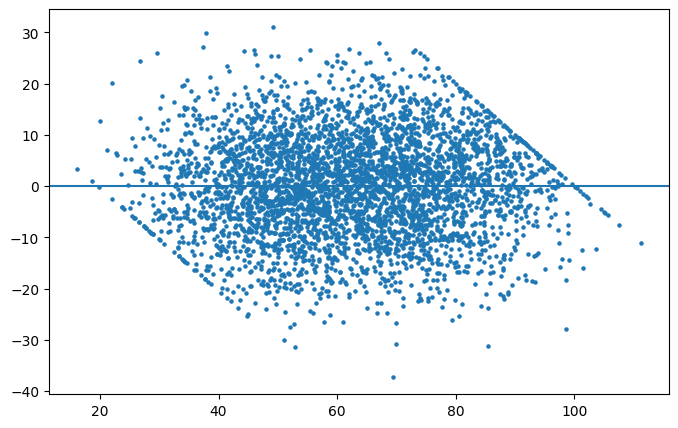

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residual, s=5)
plt.axhline(0)
plt.show()

In [34]:
import joblib
joblib.dump(pipe,'student_exam_score_model.pkl')

['student_exam_score_model.pkl']

In [36]:
model = joblib.load('student_exam_score_model.pkl')
new_student = pd.DataFrame({
    'age': [20],
    'course': ['bca'],
    'study_hours': [6.5],
    'class_attendance': [82.0],
    'sleep_hours': [7.5],
    'sleep_quality': ['good'],
    'study_method': ['self-study'],
    'facility_rating': ['high'],
    'exam_difficulty': ['moderate']
})
prediction = model.predict(new_student)

print("Predicted Exam Score:", prediction[0])

Predicted Exam Score: 87.42678135958991
